# OASIS-3: Final Discordance-Centered Longitudinal Reliability Analysis

This notebook is **standalone**. It does not require the original OASIS modeling notebook to be open and does not depend on variables existing in the kernel.

It reuses the saved subject-disjoint `outer_repeats/test.csv` and `oof.csv` artifacts and the already-computed Triad 1488-D embeddings.

## Central construct

The primary discordance is **current-visit state discordance**:

\[
D_{state}=|Z_{brain}-Z_{cognition}|
\]

where the brain index is an age-prediction deviation from the Triad MRI representation and the cognition index is an age/sex-adjusted MMSE impairment score.

The notebook then asks whether state discordance:
1. predicts future forecast error,
2. identifies large-error forecasts,
3. supports selective prediction and discordance-aware routing,
4. has directional and temporal structure,
5. bridges to legacy prediction-level discordance,
6. survives residualization and a matched permutation negative control,
7. remains visible with a conventional FreeSurfer representation.

All state normative models are leakage-controlled: OOF scores are cross-fitted by subject, and held-out scores use only development subjects.

In [10]:
import gc, json, math, random, warnings, re, os, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score
)
import joblib

warnings.filterwarnings("ignore")
SEED = 42
rng_global = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)

def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 10 or np.unique(x).size < 3 or np.unique(y).size < 3:
        return np.nan, np.nan
    r, p = spearmanr(x, y)
    return float(r), float(p)

def bootstrap_rho(df, x, y, n_boot=2000, seed=42):
    d = df[[x, y, "subject_id"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    d = d.groupby("subject_id", as_index=False)[[x, y]].mean()
    if len(d) < 10:
        return {"N_subjects": int(len(d)), "rho": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    r, _ = safe_spearman(d[x], d[y])
    rng = np.random.default_rng(seed)
    vals = []
    subs = d.index.to_numpy()
    for _ in range(n_boot):
        idx = rng.choice(subs, size=len(subs), replace=True)
        b = d.loc[idx]
        rr, _ = safe_spearman(b[x], b[y])
        if np.isfinite(rr):
            vals.append(rr)
    q = np.quantile(vals, [0.025, 0.975]) if vals else [np.nan, np.nan]
    return {"N_subjects": int(len(d)), "rho": r, "ci_low": float(q[0]), "ci_high": float(q[1])}

def risk_curve(df, score, error="abs_error", coverages=None):
    if coverages is None:
        coverages = np.array([.2,.3,.4,.5,.6,.7,.8,.9,1.0])
    d = df[[score, error]].replace([np.inf,-np.inf],np.nan).dropna().sort_values(score).reset_index(drop=True)
    rows=[]
    if d.empty:
        return pd.DataFrame()
    for c in coverages:
        n=max(1,int(round(c*len(d))))
        rows.append({"score":score,"coverage":n/len(d),"N":n,"MAE":float(d.iloc[:n][error].mean())})
    return pd.DataFrame(rows)

def aurc(rc):
    if rc.empty: return np.nan
    z=rc.sort_values("coverage")
    return float(np.trapezoid(z["MAE"], z["coverage"]))

def top_fraction_enrichment(df, score, event_col, frac=0.20):
    d=df[[score,event_col]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    if len(d)<10 or d[event_col].sum()==0:
        return {"N":len(d),"top_N":0,"event_total":int(d[event_col].sum()),"event_top":np.nan,"capture":np.nan,"enrichment":np.nan}
    n=max(1,int(round(frac*len(d))))
    top=d.sort_values(score,ascending=False).head(n)
    total=d[event_col].sum()
    ev=top[event_col].sum()
    base=total/len(d)
    return {"N":len(d),"top_N":n,"event_total":int(total),"event_top":int(ev),
            "capture":float(ev/total),"enrichment":float((ev/n)/base) if base>0 else np.nan}

def quantile_threshold(dev, col, q=.75):
    x=pd.to_numeric(dev[col],errors="coerce").replace([np.inf,-np.inf],np.nan).dropna()
    return float(x.quantile(q)) if len(x) else np.nan

def infer_date_col(df):
    for c in ["clinical_date","clinical_day","anchor_clinical_date","date","visit_date"]:
        if c in df.columns: return c
    return None

In [11]:
# ============================================================
# 1. LOAD SAVED OASIS OUTER-REPEAT ARTIFACTS + CURRENT-VISIT DATA
# ============================================================
PROJECT_ROOT = Path(r"C:\Projects\OASIS\oasis_raw_t1_encoder")
PAPER_ROOT = PROJECT_ROOT / "PAPER_READY_FINAL_RESULTS"
REPEAT_ROOT = PAPER_ROOT / "outer_repeats"
EMBED_ROOT = PROJECT_ROOT / "triad_embeddings"
STRUCTURED_ROOT = Path(r"C:\Projects\OASIS\OASIS3_data_files")
OUT_ROOT = PAPER_ROOT / "DISCORDANCE_FINAL_ANALYSIS"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def load_repeats(root):
    tests=[]; oofs=[]
    for d in sorted(root.glob("repeat_*")):
        rep=int(d.name.split("_")[-1])
        tf=d/"test.csv"; of=d/"oof.csv"
        if not tf.exists() or not of.exists():
            continue
        t=pd.read_csv(tf); o=pd.read_csv(of)
        t["repeat"]=rep; o["repeat"]=rep
        tests.append(t); oofs.append(o)
    if not tests:
        raise FileNotFoundError("No saved outer-repeat test/oof CSVs found.")
    return pd.concat(tests,ignore_index=True), pd.concat(oofs,ignore_index=True)

test_all, oof_all = load_repeats(REPEAT_ROOT)

B4_FILE = next(STRUCTURED_ROOT.rglob("OASIS3_UDSb4_cdr.csv"))
DEMO_FILE = next(STRUCTURED_ROOT.rglob("OASIS3_demographics.csv"))
FS_FILE = next(STRUCTURED_ROOT.rglob("OASIS3_Freesurfer_output.csv"))

b4=pd.read_csv(B4_FILE,low_memory=False)
demo=pd.read_csv(DEMO_FILE,low_memory=False)
fs=pd.read_csv(FS_FILE,low_memory=False)

def sid_clean(x):
    m=re.search(r"OAS\d{5}",str(x).upper())
    return m.group(0) if m else np.nan

def days_clean(x):
    m=re.search(r"[._-]d(\d{4,5})(?:\D|$)",str(x),flags=re.I)
    return int(m.group(1)) if m else np.nan

clinical=pd.DataFrame({
    "subject_id":b4["OASISID"].map(sid_clean),
    "clinical_day":pd.to_numeric(b4["days_to_visit"],errors="coerce"),
    "anchor_age":pd.to_numeric(b4["age at visit"],errors="coerce"),
    "anchor_mmse":pd.to_numeric(b4["MMSE"],errors="coerce"),
    "cdrsum":pd.to_numeric(b4["CDRSUM"],errors="coerce"),
})
demo["subject_id"]=demo["OASISID"].map(sid_clean)
sex_col=next((c for c in ["M/F","sex","Sex","SEX","gender","Gender"] if c in demo.columns),None)
if sex_col:
    sexmap=demo[["subject_id",sex_col]].dropna().drop_duplicates("subject_id")
    sexmap=sexmap.rename(columns={sex_col:"sex"})
else:
    sexmap=pd.DataFrame({"subject_id":demo["subject_id"].dropna().unique(),"sex":"UNK"})
clinical=clinical.merge(sexmap,on="subject_id",how="left")
clinical=clinical.dropna(subset=["subject_id","clinical_day"]).drop_duplicates(["subject_id","clinical_day"],keep="last")

emb_manifest=pd.read_csv(EMBED_ROOT/"embedding_manifest.csv",low_memory=False)
emb_manifest["subject_id"]=emb_manifest["subject_id"].map(sid_clean)
emb_manifest["mri_day"]=pd.to_numeric(emb_manifest["mri_day"],errors="coerce")
emb_manifest=emb_manifest[
    emb_manifest["status"].eq("OK") &
    emb_manifest["embedding_dim"].eq(1488)
].copy()

# Anchor each saved test/OOF row to its contemporaneous MRI embedding.
def attach_current_metadata(frame):
    d=frame.copy()
    d["clinical_day"]=pd.to_numeric(d["clinical_day"],errors="coerce")
    d=d.merge(
        clinical[["subject_id","clinical_day","anchor_age","anchor_mmse","cdrsum","sex"]],
        on=["subject_id","clinical_day"],how="left",suffixes=("","_clinical")
    )
    embed_lookup={sid:g.sort_values("mri_day") for sid,g in emb_manifest.groupby("subject_id")}
    paths=[]
    gaps=[]
    for _,r in d.iterrows():
        g=embed_lookup.get(r["subject_id"])
        if g is None:
            paths.append(None); gaps.append(np.nan); continue
        el=g[(g["mri_day"]<=r["clinical_day"]) & ((r["clinical_day"]-g["mri_day"])<=180)]
        if el.empty:
            paths.append(None); gaps.append(np.nan)
        else:
            j=(r["clinical_day"]-el["mri_day"]).abs().idxmin()
            m=el.loc[j]
            paths.append(m["embedding_path"])
            gaps.append(float(r["clinical_day"]-m["mri_day"]))
    d["embedding_path"]=paths
    d["mri_gap_days"]=gaps
    return d

test_meta=attach_current_metadata(test_all)
oof_meta=attach_current_metadata(oof_all)

def load_embedding_cache(df):
    cache={}
    X=np.full((len(df),1488),np.nan,dtype=np.float32)
    for i,p in enumerate(df["embedding_path"]):
        if pd.isna(p): continue
        key=str(p)
        if key not in cache:
            try:
                z=np.load(key,mmap_mode="r")
                z=np.asarray(z,dtype=np.float32)
                if z.ndim!=1 or len(z)!=1488 or not np.isfinite(z).all():
                    cache[key]=None
                else:
                    cache[key]=z.copy()
            except Exception:
                cache[key]=None
        if cache[key] is not None:
            X[i]=cache[key]
    return X

test_X=load_embedding_cache(test_meta)
oof_X=load_embedding_cache(oof_meta)

print("Loaded repeats:", sorted(test_all.repeat.unique().tolist()))
print("Held-out rows:",len(test_meta),"OOF rows:",len(oof_meta))
print("Usable test embeddings:",int(np.isfinite(test_X).all(axis=1).sum()))
print("Usable OOF embeddings:",int(np.isfinite(oof_X).all(axis=1).sum()))

Loaded repeats: [1, 2, 3, 4, 5, 6]
Held-out rows: 311 OOF rows: 1219
Usable test embeddings: 311
Usable OOF embeddings: 1219


In [12]:
# ============================================================
# STATE-LEVEL DISCORDANCE ENGINE
# ============================================================
# Definition:
#   brain_abnormality = age-prediction deviation from chronological age
#   cognitive_impairment = age/sex-adjusted MMSE impairment
#   state_discordance = |brain_abnormality - cognitive_impairment|
#   signed_state_discordance = brain_abnormality - cognitive_impairment
#
# All normative fits are leakage-controlled:
#   - OOF development scores are cross-fitted across subjects.
#   - Held-out test scores are scored using a model fit only on OOF development data.
# The current future outcome is NEVER used to construct state discordance.

def weighted_subject_sample(df):
    d = df.copy()
    counts = d.groupby("subject_id")["subject_id"].transform("size")
    d["_w"] = 1.0 / counts.clip(lower=1)
    return d

def fit_brain_age_model(X, age, subject_ids, sex=None, n_pca=64, alpha=10.0):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(age, dtype=float)
    m = np.isfinite(y) & np.isfinite(X).all(axis=1)
    X, y = X[m], y[m]
    sid = np.asarray(subject_ids)[m]
    sex_arr = np.asarray(sex if sex is not None else ["UNK"] * len(y), dtype=object)[m]
    if len(y) < 25:
        raise RuntimeError("Too few rows to fit the MRI age model.")
    prep = StandardScaler()
    Z = prep.fit_transform(X)
    ncomp = int(min(n_pca, Z.shape[1], max(2, Z.shape[0]-1)))
    pca = PCA(n_components=ncomp, random_state=SEED)
    Z = pca.fit_transform(Z)
    reg = Ridge(alpha=alpha)
    # subject-balanced weights
    _, counts = np.unique(sid, return_counts=True)
    weight_map = dict(zip(np.unique(sid), 1.0/np.maximum(counts,1)))
    sw = np.array([weight_map[s] for s in sid], dtype=float)
    reg.fit(Z, y, sample_weight=sw)
    pred = reg.predict(Z)
    gap = pred - y

    gap_mean_by_sex = {}
    gap_sd_by_sex = {}
    for sx in np.unique(sex_arr.astype(str)):
        g = gap[sex_arr.astype(str) == sx]
        if len(g) >= 5:
            gap_mean_by_sex[str(sx)] = float(np.mean(g))
            gap_sd_by_sex[str(sx)] = float(max(np.std(g, ddof=1), 1e-6))

    return {
        "scaler":prep,
        "pca":pca,
        "ridge":reg,
        "gap_mean_by_sex":gap_mean_by_sex,
        "gap_sd_by_sex":gap_sd_by_sex,
        "gap_mean_global":float(np.mean(gap)),
        "gap_sd_global":float(max(np.std(gap, ddof=1), 1e-6)),
    }

def predict_brain_age(model, X):
    X=np.asarray(X,dtype=np.float32)
    Z=model["scaler"].transform(X)
    Z=model["pca"].transform(Z)
    return model["ridge"].predict(Z)

def fit_cognitive_norm(df):
    d=df[["anchor_age","anchor_mmse","sex","subject_id"]].copy()
    d["age2"]=d["anchor_age"]**2
    d=d.replace([np.inf,-np.inf],np.nan).dropna(subset=["anchor_age","anchor_mmse"])
    if len(d)<25:
        raise RuntimeError("Too few rows to fit the clinical normative model.")
    sex = d["sex"].fillna("UNK").astype(str)
    X = pd.DataFrame({
        "age": d["anchor_age"].astype(float),
        "age2": d["age2"].astype(float),
        "male": sex.str.upper().str.startswith("M").astype(float),
        "female": sex.str.upper().str.startswith("F").astype(float),
    }, index=d.index)
    y=d["anchor_mmse"].astype(float).to_numpy()
    reg=Ridge(alpha=10.0)
    ws=weighted_subject_sample(d)["_w"].to_numpy()
    reg.fit(X,y,sample_weight=ws)
    return {"model":reg}

def predict_cognitive_expected(model, age, sex):
    age=np.asarray(age,float)
    sex=pd.Series(sex).fillna("UNK").astype(str)
    X=pd.DataFrame({
        "age":age,
        "age2":age**2,
        "male":sex.str.upper().str.startswith("M").astype(float).to_numpy(),
        "female":sex.str.upper().str.startswith("F").astype(float).to_numpy(),
    })
    return model["model"].predict(X)

def fit_state_norm(train_df, X_train, n_pca=64, alpha=10.0):
    ok = train_df["anchor_age"].notna() & train_df["anchor_mmse"].notna()
    tr = train_df.loc[ok].reset_index(drop=True)
    X = np.asarray(X_train)[ok.to_numpy()]
    brain_model = fit_brain_age_model(
        X,
        tr["anchor_age"].to_numpy(),
        tr["subject_id"].to_numpy(),
        sex=tr["sex"].to_numpy(),
        n_pca=n_pca,
        alpha=alpha,
    )
    cog_model = fit_cognitive_norm(tr)

    brain_pred = predict_brain_age(brain_model, X)
    brain_gap = brain_pred - tr["anchor_age"].to_numpy()
    cog_expected = predict_cognitive_expected(
        cog_model, tr["anchor_age"].to_numpy(), tr["sex"].to_numpy()
    )
    cog_imp = cog_expected - tr["anchor_mmse"].to_numpy()

    cog_sd = float(np.std(cog_imp, ddof=1))
    cog_sd = max(cog_sd, 1e-6)

    return {
        "brain_model":brain_model,
        "cognitive_model":cog_model,
        "cognitive_sd":cog_sd,
    }

def score_state_norm(model, df, X):
    age=df["anchor_age"].to_numpy(dtype=float)
    mmse=df["anchor_mmse"].to_numpy(dtype=float)
    brain_pred=predict_brain_age(model["brain_model"], X)
    brain_gap=brain_pred-age
    sex_vals=pd.Series(df["sex"]).fillna("UNK").astype(str).to_numpy()
    brain_z=np.empty(len(brain_gap),dtype=float)
    global_mean=model["brain_model"]["gap_mean_global"]
    global_sd=model["brain_model"]["gap_sd_global"]
    for i,sx in enumerate(sex_vals):
        mu=model["brain_model"]["gap_mean_by_sex"].get(str(sx),global_mean)
        sd=model["brain_model"]["gap_sd_by_sex"].get(str(sx),global_sd)
        brain_z[i]=(brain_gap[i]-mu)/max(sd,1e-6)

    cog_expected=predict_cognitive_expected(
        model["cognitive_model"], age, df["sex"].to_numpy()
    )
    cog_imp=cog_expected-mmse

    out=df.copy()
    out["brain_age_pred"]=brain_pred
    out["brain_age_gap"]=brain_gap
    out["brain_abnormality_z"]=brain_z
    out["cognitive_expected_mmse"]=cog_expected
    out["cognitive_impairment_z"]=cog_imp/model["cognitive_sd"]
    out["state_discordance"]=(
        out["brain_abnormality_z"]-out["cognitive_impairment_z"]
    ).abs()
    out["signed_state_discordance"]=(
        out["brain_abnormality_z"]-out["cognitive_impairment_z"]
    )
    return out

In [13]:
# ============================================================
# 2. LEAKAGE-CONTROLLED STATE DISCORDANCE
# ============================================================
# For each outer repeat:
#   OOF state scores = cross-fitted within the development subjects.
#   TEST state scores = trained only on that repeat's OOF development data.

def crossfit_state_scores(dev_df, dev_X, n_splits=5):
    out=dev_df.copy().reset_index(drop=True)
    out["state_discordance"]=np.nan
    out["signed_state_discordance"]=np.nan
    out["brain_age_gap"]=np.nan
    out["brain_abnormality_z"]=np.nan
    out["cognitive_impairment_z"]=np.nan
    groups=out["subject_id"].astype(str).to_numpy()
    n_groups=len(np.unique(groups))
    k=min(n_splits,n_groups)
    if k<2:
        return out
    gkf=GroupKFold(n_splits=k)
    for fi,vi in gkf.split(out,groups=groups):
        tr=out.iloc[fi].reset_index(drop=True)
        va=out.iloc[vi].reset_index(drop=True)
        Xtr=dev_X[fi]
        Xva=dev_X[vi]
        oktr=np.isfinite(Xtr).all(axis=1) & tr["anchor_age"].notna().to_numpy() & tr["anchor_mmse"].notna().to_numpy()
        okva=np.isfinite(Xva).all(axis=1) & va["anchor_age"].notna().to_numpy() & va["anchor_mmse"].notna().to_numpy()
        if oktr.sum()<25 or okva.sum()==0:
            continue
        model = fit_state_norm(
    tr.loc[oktr].reset_index(drop=True),
    Xtr[oktr]
)

        scored = score_state_norm(
    model,
    va.loc[okva].reset_index(drop=True),
    Xva[okva]
)
        target_indices=np.asarray(vi)[np.flatnonzero(okva)]
        for col in ["state_discordance","signed_state_discordance","brain_age_gap","brain_abnormality_z","cognitive_impairment_z"]:
            out.loc[target_indices,col]=scored[col].to_numpy()
    return out

repeat_state_results=[]
repeat_oof_state=[]
repeat_test_state=[]
repeat_norm_models={}

for rep in sorted(test_meta.repeat.unique()):
    dev=oof_meta[oof_meta.repeat.eq(rep)].reset_index(drop=True)
    te=test_meta[test_meta.repeat.eq(rep)].reset_index(drop=True)
    dev_idx=oof_meta.index[oof_meta.repeat.eq(rep)].to_numpy()
    te_idx=test_meta.index[test_meta.repeat.eq(rep)].to_numpy()

    dev_X_local=oof_X[dev_idx]
    te_X_local=test_X[te_idx]

    dev_scored=crossfit_state_scores(dev,dev_X_local,n_splits=5)

    fit_ok=np.isfinite(dev_X_local).all(axis=1) & dev["anchor_age"].notna().to_numpy() & dev["anchor_mmse"].notna().to_numpy()
    if fit_ok.sum()<25:
        print("Repeat",rep,"skipped: insufficient usable development rows.")
        continue
    final_norm=fit_state_norm(dev.loc[fit_ok].reset_index(drop=True),dev_X_local[fit_ok])
    test_ok=np.isfinite(te_X_local).all(axis=1) & te["anchor_age"].notna().to_numpy() & te["anchor_mmse"].notna().to_numpy()
    te_scored = score_state_norm(
    final_norm,
    te.loc[test_ok].reset_index(drop=True),
    te_X_local[test_ok]
)

    # Explicitly add back test prediction metrics.
    if not te_scored.empty:
        te_scored["repeat"]=rep
        rep_te=te_scored
    else:
        rep_te=pd.DataFrame()

    dev_scored["repeat"]=rep
    repeat_oof_state.append(dev_scored)
    if not rep_te.empty: repeat_test_state.append(rep_te)
    repeat_norm_models[rep]=final_norm

oof_state=pd.concat(repeat_oof_state,ignore_index=True) if repeat_oof_state else pd.DataFrame()
test_state=pd.concat(repeat_test_state,ignore_index=True) if repeat_test_state else pd.DataFrame()

print("Cross-fitted OOF state rows:",len(oof_state))
print("Held-out state rows:",len(test_state))
print("Subjects in held-out state:",test_state["subject_id"].nunique() if not test_state.empty else 0)

Cross-fitted OOF state rows: 1219
Held-out state rows: 311
Subjects in held-out state: 159


In [14]:
# ============================================================
# 3. PRIMARY: STATE DISCORDANCE -> FUTURE FORECAST ERROR
# ============================================================
primary_rows=[]
bootstrap_rows=[]
for rep in sorted(test_state["repeat"].unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    if d.empty: continue
    # Subject-average for inferential stability.
    agg=d.groupby("subject_id",as_index=False).agg(
        state_discordance=("state_discordance","mean"),
        signed_state_discordance=("signed_state_discordance","mean"),
        abs_error=("abs_error","mean"),
        prediction_disagreement=("prediction_disagreement","mean"),
        uncertainty=("uncertainty","mean"),
        anchor_mmse=("anchor_mmse","mean"),
        n_mri=("n_mri","mean"),
        n_clinical=("n_clinical","mean"),
    )
    r,p=safe_spearman(agg.state_discordance,agg.abs_error)
    primary_rows.append({
        "repeat":rep,"N_subjects":len(agg),"rho_state_discordance_error":r,"p":p,
        "rho_prediction_disagreement_error":safe_spearman(agg.prediction_disagreement,agg.abs_error)[0],
        "rho_uncertainty_error":safe_spearman(agg.uncertainty,agg.abs_error)[0]
    })
    b=bootstrap_rho(agg.rename(columns={"state_discordance":"state_discordance"}),"state_discordance","abs_error",seed=SEED+rep)
    b["repeat"]=rep
    bootstrap_rows.append(b)

primary=pd.DataFrame(primary_rows)
primary_bootstrap=pd.DataFrame(bootstrap_rows)

print("PRIMARY STATE DISCORDANCE -> ERROR")
display(primary)
print("\nBootstrap subject-level uncertainty:")
display(primary_bootstrap)

def repeated_summary(df, col):
    x=pd.to_numeric(df[col],errors="coerce").dropna()
    return {
        "mean":float(x.mean()) if len(x) else np.nan,
        "median":float(x.median()) if len(x) else np.nan,
        "sd":float(x.std(ddof=1)) if len(x)>1 else np.nan,
        "positive":int((x>0).sum()) if len(x) else 0,
        "n":int(len(x))
    }

print("\nAcross-repeat summary:", repeated_summary(primary,"rho_state_discordance_error"))

PRIMARY STATE DISCORDANCE -> ERROR


,repeat,N_subjects,rho_state_discordance_error,p,rho_prediction_disagreement_error,rho_uncertainty_error
0,1,43,0.067502,0.667130,0.138025,0.194654
1,2,43,0.000755,0.996166,0.297946,0.178345
2,3,43,0.205678,0.185777,0.437330,0.585624
3,4,43,0.026276,0.867169,0.260042,0.183781
4,5,43,-0.103594,0.508563,0.307611,0.215494
5,6,43,0.030504,0.846034,0.485805,0.220930



Bootstrap subject-level uncertainty:


,N_subjects,rho,ci_low,ci_high,repeat
0,43,0.067502,-0.266708,0.409589,1
1,43,0.000755,-0.317895,0.316677,2
2,43,0.205678,-0.147592,0.517960,3
3,43,0.026276,-0.276869,0.303032,4
4,43,-0.103594,-0.457917,0.248642,5
5,43,0.030504,-0.309121,0.365624,6



Across-repeat summary: {'mean': 0.03785361924896808, 'median': 0.028390214436726062, 'sd': 0.10061400073703346, 'positive': 5, 'n': 6}


In [15]:
# ============================================================
# 4. DISCORDANCE-STRATIFIED FAILURE DETECTION
# ============================================================
# Fixed large-error endpoint avoids choosing the failure threshold on test data.
FIXED_ERROR_THRESHOLD=2.0
failure_rows=[]
enrichment_rows=[]

for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    d["large_error"]=(d["abs_error"]>=FIXED_ERROR_THRESHOLD).astype(int)
    # OOF-derived 75th-percentile state threshold.
    dev=oof_state[oof_state.repeat.eq(rep)]
    thr=quantile_threshold(dev,"state_discordance",.75)
    d["high_state_discordance"]=(d["state_discordance"]>=thr).astype(int) if np.isfinite(thr) else np.nan

    n_top=max(1,int(round(.20*len(d))))
    top=d.nlargest(n_top,"state_discordance")
    total=d["large_error"].sum()
    top_ev=top["large_error"].sum()
    capture=float(top_ev/total) if total>0 else np.nan
    base=float(total/len(d)) if len(d) else np.nan
    enr=float((top_ev/n_top)/base) if base and base>0 else np.nan

    auroc=np.nan
    auprc=np.nan
    if d["large_error"].nunique()==2 and d["state_discordance"].nunique()>1:
        auroc=float(roc_auc_score(d.large_error,d.state_discordance))
        auprc=float(average_precision_score(d.large_error,d.state_discordance))

    failure_rows.append({
        "repeat":rep,"N":len(d),"large_errors":int(total),
        "state_AUROC":auroc,"state_AUPRC":auprc,
        "OOF_state_q75":thr,
        "high_discordance_MAE":float(d.loc[d.high_state_discordance.eq(1),"abs_error"].mean()) if d.high_state_discordance.eq(1).any() else np.nan,
        "low_discordance_MAE":float(d.loc[d.high_state_discordance.eq(0),"abs_error"].mean()) if d.high_state_discordance.eq(0).any() else np.nan
    })
    enrichment_rows.append({
        "repeat":rep,"top_fraction":.20,"top_N":n_top,
        "large_error_total":int(total),"large_error_in_top":int(top_ev),
        "capture":capture,"enrichment":enr
    })

failure=pd.DataFrame(failure_rows)
enrichment=pd.DataFrame(enrichment_rows)
display(failure)
display(enrichment)

,repeat,N,large_errors,state_AUROC,state_AUPRC,OOF_state_q75,high_discordance_MAE,low_discordance_MAE
0,1,54,7,0.504559,0.215572,1.837390,2.152186,1.024641
1,2,54,9,0.501235,0.278309,2.002658,2.695734,1.197366
2,3,51,11,0.645455,0.567972,2.095387,4.888580,1.097738
3,4,52,10,0.530952,0.299162,2.092212,1.495077,1.121058
4,5,46,5,0.458537,0.287240,1.998734,3.524030,0.767789
5,6,54,13,0.553471,0.394483,2.066250,2.460545,1.481675


,repeat,top_fraction,top_N,large_error_total,large_error_in_top,capture,enrichment
0,1,0.2,11,7,2,0.285714,1.402597
1,2,0.2,11,9,2,0.222222,1.090909
2,3,0.2,10,11,6,0.545455,2.781818
3,4,0.2,10,10,2,0.200000,1.040000
4,5,0.2,9,5,1,0.200000,1.022222
5,6,0.2,11,13,4,0.307692,1.510490


In [16]:
# ============================================================
# 5. SELECTIVE PREDICTION / RISK-COVERAGE
# ============================================================
# Calibration is learned on cross-fitted OOF state scores only.
# Ranking is done on held-out test data.
COVERAGES=np.array([.20,.30,.40,.50,.60,.70,.80,.90,1.0])
selective_rows=[]
for rep in sorted(test_state.repeat.unique()):
    dev=oof_state[oof_state.repeat.eq(rep)].copy()
    te=test_state[test_state.repeat.eq(rep)].copy()
    for score in ["state_discordance","prediction_disagreement","uncertainty","signed_abs"]:
        if score=="signed_abs":
            dev["signed_abs"]=dev["signed_state_discordance"].abs()
            te["signed_abs"]=te["signed_state_discordance"].abs()
        if score not in dev.columns or score not in te.columns: continue
        dc=dev[[score,"abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
        tc=te[[score,"abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
        if len(dc)<25 or len(tc)<10 or dc[score].nunique()<5: continue
        iso=IsotonicRegression(increasing=True,out_of_bounds="clip")
        iso.fit(dc[score],dc["abs_error"])
        tc=tc.copy()
        tc["predicted_error"]=iso.predict(tc[score])
        tc=tc.sort_values("predicted_error").reset_index(drop=True)
        for c in COVERAGES:
            n=max(1,int(round(c*len(tc))))
            selective_rows.append({
                "repeat":rep,"score":score,"coverage":n/len(tc),
                "N":n,"MAE":float(tc.iloc[:n]["abs_error"].mean())
            })

selective=pd.DataFrame(selective_rows)
aurc_rows=[]
for (rep,score),d in selective.groupby(["repeat","score"]):
    aurc_rows.append({"repeat":rep,"score":score,"AURC":aurc(d)})
aurc=pd.DataFrame(aurc_rows)

display(aurc.groupby("score")["AURC"].agg(["mean","median","std","count"]).sort_values("mean"))

,mean,median,std,count
score,,,,
uncertainty,0.819724,0.883899,0.162381,6
prediction_disagreement,0.821163,0.845931,0.163880,6
signed_abs,0.935045,0.923387,0.227778,6
state_discordance,0.935045,0.923387,0.227778,6


In [17]:
# ============================================================
# 6. DISCORDANCE-AWARE ROUTING / ABSTENTION
# ============================================================
# Policy thresholds come from OOF only.
routing_rows=[]
for rep in sorted(test_state.repeat.unique()):
    dev=oof_state[oof_state.repeat.eq(rep)].copy()
    te=test_state[test_state.repeat.eq(rep)].copy()

    # State-discordance policy: high discordance -> clinical fallback.
    state_thr=quantile_threshold(dev,"state_discordance",.75)
    pred_thr=quantile_threshold(dev,"prediction_disagreement",.75)
    unc_thr=quantile_threshold(dev,"uncertainty",.75)

    policies={
        "always_joint": te["prediction"],
        "always_clinical": te["clinical_prediction"],
        "state_high_fallback_clinical": np.where(te["state_discordance"]>=state_thr, te["clinical_prediction"], te["prediction"]) if np.isfinite(state_thr) else te["prediction"],
        "prediction_discordance_high_fallback_clinical": np.where(te["prediction_disagreement"]>=pred_thr, te["clinical_prediction"], te["prediction"]) if np.isfinite(pred_thr) else te["prediction"],
        "state_and_uncertainty_high_fallback_clinical": np.where((te["state_discordance"]>=state_thr)&(te["uncertainty"]>=unc_thr), te["clinical_prediction"], te["prediction"]) if np.isfinite(state_thr) and np.isfinite(unc_thr) else te["prediction"],
    }
    for name,pred in policies.items():
        routing_rows.append({
            "repeat":rep,"policy":name,
            "MAE":float(mean_absolute_error(te["future_mmse"],pred)),
            "RMSE":float(np.sqrt(mean_squared_error(te["future_mmse"],pred))),
            "N":len(te)
        })

routing=pd.DataFrame(routing_rows)
display(routing.groupby("policy")["MAE"].agg(["mean","median","std","count"]).sort_values("mean"))

,mean,median,std,count
policy,,,,
prediction_discordance_high_fallback_clinical,1.317302,1.323004,0.333800,6
always_clinical,1.323709,1.298210,0.307975,6
state_high_fallback_clinical,1.357043,1.324894,0.339396,6
always_joint,1.358416,1.334425,0.353769,6
state_and_uncertainty_high_fallback_clinical,1.360978,1.344045,0.343928,6


In [18]:
# ============================================================
# 7. SIGNED DIRECTION + TEMPORAL CHANGE
# ============================================================
direction_rows=[]
temporal_rows=[]
for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    time_col = "clinical_day" if "clinical_day" in d.columns else (
        "clinical_date" if "clinical_date" in d.columns else "anchor_clinical_date"
    )
    if time_col in d.columns:
        d[time_col] = pd.to_datetime(d[time_col], errors="coerce") if "date" in time_col else pd.to_numeric(d[time_col], errors="coerce")
        d=d.sort_values(["subject_id",time_col])
    else:
        d=d.sort_values(["subject_id"])
    d["direction"]=np.select(
        [d["signed_state_discordance"]>0.5,d["signed_state_discordance"]<-0.5],
        ["brain_more_abnormal","cognition_more_abnormal"],
        default="aligned"
    )
    for grp,g in d.groupby("direction"):
        if len(g)>=10:
            direction_rows.append({
                "repeat":rep,"direction":grp,"N":len(g),
                "MAE":float(g["abs_error"].mean()),
                "median_abs_error":float(g["abs_error"].median())
            })
    if "clinical_day" in d.columns:
        d["delta_state_discordance"]=d.groupby("subject_id")["state_discordance"].diff()
        q=d.dropna(subset=["delta_state_discordance","abs_error"])
        if len(q)>=10:
            agg=q.groupby("subject_id",as_index=False)[["delta_state_discordance","abs_error"]].mean()
            r,p=safe_spearman(agg.delta_state_discordance,agg.abs_error)
            temporal_rows.append({"repeat":rep,"N_subjects":len(agg),"rho_delta_discordance_error":r,"p":p})

directional=pd.DataFrame(direction_rows)
temporal=pd.DataFrame(temporal_rows)
print("Directional discordance:")
display(directional)
print("Temporal change in discordance:")
display(temporal)

Directional discordance:


,repeat,direction,N,MAE,median_abs_error
0,1,aligned,17,1.363934,1.140304
1,1,brain_more_abnormal,20,0.810533,0.662812
2,1,cognition_more_abnormal,17,1.202543,0.767752
3,2,aligned,13,1.416510,0.672768
4,2,brain_more_abnormal,25,0.884827,0.569717
5,2,cognition_more_abnormal,16,2.350486,1.482509
6,3,aligned,13,1.444568,1.160554
7,3,brain_more_abnormal,19,0.804668,0.602013
8,3,cognition_more_abnormal,19,3.148684,1.855258
9,4,aligned,11,1.137709,1.278424


Temporal change in discordance:


,repeat,N_subjects,rho_delta_discordance_error,p
0,1,10,-0.103030,0.776998
1,2,10,0.309091,0.384841
2,6,9,NaN,NaN


In [19]:
# ============================================================
# 8. STATE vs FORECAST DISCORDANCE
# ============================================================
bridge_rows=[]
for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    agg=d.groupby("subject_id",as_index=False).agg(
        state_discordance=("state_discordance","mean"),
        forecast_discordance=("prediction_disagreement","mean"),
        abs_error=("abs_error","mean"),
        uncertainty=("uncertainty","mean")
    )
    r1,p1=safe_spearman(agg.state_discordance,agg.forecast_discordance)
    r2,p2=safe_spearman(agg.state_discordance,agg.abs_error)
    r3,p3=safe_spearman(agg.forecast_discordance,agg.abs_error)
    bridge_rows.append({
        "repeat":rep,"N_subjects":len(agg),
        "state_vs_forecast_rho":r1,
        "state_vs_error_rho":r2,
        "forecast_vs_error_rho":r3
    })

bridge=pd.DataFrame(bridge_rows)
display(bridge)

,repeat,N_subjects,state_vs_forecast_rho,state_vs_error_rho,forecast_vs_error_rho
0,1,43,-0.044548,0.067502,0.138025
1,2,43,0.280731,0.000755,0.297946
2,3,43,-0.038206,0.205678,0.437330
3,4,43,-0.063576,0.026276,0.260042
4,5,43,0.242223,-0.103594,0.307611
5,6,43,-0.002869,0.030504,0.485805


In [20]:
# ============================================================
# 9. RESIDUALIZED FORECAST DISCORDANCE
# ============================================================
# Diagnostic only. Models are fit on OOF and applied to test.
resid_rows=[]
base_cols=["uncertainty","raw_view_spread","clinical_view_spread","anchor_mmse","n_mri","n_clinical","future_interval_years"]
for rep in sorted(test_state.repeat.unique()):
    dev=oof_state[oof_state.repeat.eq(rep)].copy()
    te=test_state[test_state.repeat.eq(rep)].copy()
    cols=[c for c in base_cols if c in dev.columns and c in te.columns]
    if len(cols)<2 or "prediction_disagreement" not in dev.columns:
        continue
    D=dev[cols+["prediction_disagreement","abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
    T=te[cols+["prediction_disagreement","abs_error","subject_id"]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(D)<30 or len(T)<10: continue
    md=make_pipeline(StandardScaler(),Ridge(alpha=10.0)).fit(D[cols],D["prediction_disagreement"])
    me=make_pipeline(StandardScaler(),Ridge(alpha=10.0)).fit(D[cols],D["abs_error"])
    T["d_resid"]=T["prediction_disagreement"]-md.predict(T[cols])
    T["e_resid"]=T["abs_error"]-me.predict(T[cols])
    A=T.groupby("subject_id",as_index=False)[["d_resid","e_resid"]].mean()
    r,p=safe_spearman(A.d_resid,A.e_resid)
    resid_rows.append({"repeat":rep,"N_subjects":len(A),"rho_residualized":r,"p":p})
residualized=pd.DataFrame(resid_rows)
display(residualized)

,repeat,N_subjects,rho_residualized,p
0,1,43,0.044548,0.776674
1,2,43,0.134551,0.389659
2,3,43,0.226518,0.144106
3,4,43,-0.065841,0.674864
4,5,43,0.075355,0.631044
5,6,43,-0.009967,0.949422


In [22]:
# ============================================================
# 10. MATCHED SUBJECT-LEVEL PERMUTATION NEGATIVE CONTROL
# ============================================================
# We permute MRI-derived brain abnormality between subjects within
# coarse age/sex/baseline-MMSE strata, breaking true brain-cognition
# pairing while preserving broad marginal severity structure.
permutation_rows=[]
N_PERM=500

for rep in sorted(test_state.repeat.unique()):
    d=test_state[test_state.repeat.eq(rep)].copy()
    agg=d.groupby("subject_id",as_index=False).agg(
        brain_abnormality_z=("brain_abnormality_z","mean"),
        cognitive_impairment_z=("cognitive_impairment_z","mean"),
        state_discordance=("state_discordance","mean"),
        abs_error=("abs_error","mean"),
        age=("anchor_age","mean"),
        mmse=("anchor_mmse","mean"),
        sex=("sex",lambda s:s.iloc[0] if len(s) else "UNK")
    )
    r_real,_=safe_spearman(agg.state_discordance,agg.abs_error)
    rng=np.random.default_rng(SEED+10000+rep)
    age_bin=pd.cut(agg["age"],bins=[-np.inf,60,70,80,90,np.inf],labels=False)
    mmse_bin=pd.cut(agg["mmse"],bins=[-np.inf,20,24,27,30,np.inf],labels=False)
    strata=agg["sex"].astype(str)+"_"+age_bin.fillna(-1).astype(str)+"_"+mmse_bin.fillna(-1).astype(str)
    vals=[]
    for _ in range(N_PERM):
        shuffled = agg["brain_abnormality_z"].to_numpy(copy=True)
        for st in strata.unique():
            idx=np.flatnonzero(strata.to_numpy()==st)
            if len(idx)>1:
                shuffled[idx]=rng.permutation(shuffled[idx])
        perm=np.abs(shuffled-agg["cognitive_impairment_z"].to_numpy())
        rr,_=safe_spearman(perm,agg["abs_error"])
        if np.isfinite(rr): vals.append(rr)
    vals=np.asarray(vals)
    permutation_rows.append({
        "repeat":rep,"real_rho":r_real,
        "null_mean":float(np.mean(vals)) if len(vals) else np.nan,
        "null_q025":float(np.quantile(vals,.025)) if len(vals) else np.nan,
        "null_q975":float(np.quantile(vals,.975)) if len(vals) else np.nan,
        "empirical_p":float((1+np.sum(vals>=r_real))/(1+len(vals))) if len(vals) and np.isfinite(r_real) else np.nan
    })

negative_control=pd.DataFrame(permutation_rows)
display(negative_control)

,repeat,real_rho,null_mean,null_q025,null_q975,empirical_p
0,1,0.067502,0.125861,-0.131161,0.383207,0.650699
1,2,0.000755,-0.015250,-0.238523,0.211628,0.433134
2,3,0.205678,0.315626,0.108864,0.514973,0.844311
3,4,0.026276,0.108355,-0.091536,0.303507,0.798403
4,5,-0.103594,-0.015857,-0.284559,0.236998,0.728543
5,6,0.030504,-0.011866,-0.206161,0.176997,0.349301


In [23]:
# ============================================================
# 11. OASIS-ONLY: FREESURFER REPRESENTATION ROBUSTNESS
# ============================================================
# This is a state-level representation check, not another prediction model.
# It asks whether the brain-state discordance construct changes materially
# when the MRI representation is conventional FreeSurfer instead of Triad.

if "FS_FILE" in globals():
    fs0=fs.copy()
    fs0["subject_id"]=fs0["Subject"].map(sid_clean)
    fs0["mri_day"]=fs0["MR_session"].map(days_clean)

    leakage_terms=["mmse","cdr","diagnos","age","sex","gender","visit","date","day","days","session","oasisid","group"]
    numeric_candidates=[]
    for c in fs0.columns:
        if c in {"subject_id","Subject","MR_session","mri_day"}: continue
        if any(t in c.lower() for t in leakage_terms): continue
        x=pd.to_numeric(fs0[c],errors="coerce")
        if x.notna().mean()>=.40 and x.nunique(dropna=True)>=5:
            numeric_candidates.append(c)

    selected_fs=None
    feature_file=PAPER_ROOT/"selected_freesurfer_features.txt"
    if feature_file.exists():
        fs_features=[x.strip() for x in feature_file.read_text(encoding="utf-8").splitlines() if x.strip() in fs0.columns]
        if len(fs_features)>=10:
            selected_fs=fs_features
    if selected_fs is None:
        selected_fs=(
            fs0[numeric_candidates]
            .apply(pd.to_numeric,errors="coerce")
            .var(axis=0,skipna=True)
            .sort_values(ascending=False)
            .head(min(96,len(numeric_candidates))).index.tolist()
        )

    fs_session=fs0[["subject_id","mri_day"]+selected_fs].copy()
    for c in selected_fs: fs_session[c]=pd.to_numeric(fs_session[c],errors="coerce")
    fs_session=fs_session.drop_duplicates(["subject_id","mri_day"],keep="first")
    fs_lookup={sid:g.sort_values("mri_day") for sid,g in fs_session.groupby("subject_id")}

    def attach_fs_X(df):
        X=np.full((len(df),len(selected_fs)),np.nan,dtype=np.float32)
        for i,(_,r) in enumerate(df.iterrows()):
            sid=r["subject_id"]; day=float(r["clinical_day"])
            g=fs_lookup.get(sid)
            if g is None: continue
            el=g[(g["mri_day"]<=day)&((day-g["mri_day"])<=180)]
            if el.empty: continue
            j=(day-el["mri_day"]).abs().idxmin()
            X[i]=el.loc[j,selected_fs].to_numpy(dtype=np.float32)
        return X

    # We use a compact imputed PCA+Ridge age model; the fold logic mirrors Triad.
    fs_oof_X=attach_fs_X(oof_meta)
    fs_test_X=attach_fs_X(test_meta)

    def fit_fs_state(train_df,Xtr):
        ok=np.isfinite(Xtr).any(axis=1)&train_df["anchor_age"].notna()&train_df["anchor_mmse"].notna()
        tr=train_df.loc[ok].reset_index(drop=True); X=Xtr[ok]
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),
                           PCA(n_components=min(32,X.shape[1],max(2,len(X)-1)),random_state=SEED),
                           Ridge(alpha=10.0))
        w=weighted_subject_sample(tr)["_w"].to_numpy()
        pipe.fit(X,tr["anchor_age"],ridge__sample_weight=w)
        bp=pipe.predict(X)
        cog=fit_cognitive_norm(tr)
        bg=bp-tr["anchor_age"].to_numpy()
        ce=predict_cognitive_expected(cog,tr["anchor_age"],tr["sex"])
        ci=ce-tr["anchor_mmse"].to_numpy()
        return {"pipe":pipe,"cog":cog,"bsd":max(np.std(bg,ddof=1),1e-6),"csd":max(np.std(ci,ddof=1),1e-6)}

    fs_rows=[]
    for rep in sorted(test_meta.repeat.unique()):
        dev=oof_meta[oof_meta.repeat.eq(rep)].reset_index(drop=True)
        te=test_meta[test_meta.repeat.eq(rep)].reset_index(drop=True)
        Xi=fs_oof_X[oof_meta.repeat.eq(rep).to_numpy()] if isinstance(oof_meta.repeat.eq(rep),pd.Series) else fs_oof_X
        # above expression is boolean-aligned to current concatenated arrays
        Xi=fs_oof_X[np.flatnonzero(oof_meta.repeat.to_numpy()==rep)]
        Xt=fs_test_X[np.flatnonzero(test_meta.repeat.to_numpy()==rep)]
        ok=np.isfinite(Xi).any(axis=1)&dev.anchor_age.notna().to_numpy()&dev.anchor_mmse.notna().to_numpy()
        ok_t=np.isfinite(Xt).any(axis=1)&te.anchor_age.notna().to_numpy()&te.anchor_mmse.notna().to_numpy()
        if ok.sum()<25 or ok_t.sum()<10: continue
        model=fit_fs_state(dev.loc[ok].reset_index(drop=True),Xi[ok])
        bp=model["pipe"].predict(Xt[ok_t])
        bg=(bp-te.loc[ok_t,"anchor_age"].to_numpy())/model["bsd"]
        ce=predict_cognitive_expected(model["cog"],te.loc[ok_t,"anchor_age"],te.loc[ok_t,"sex"])
        ci=(ce-te.loc[ok_t,"anchor_mmse"].to_numpy())/model["csd"]
        fsd=np.abs(bg-ci)
        e=te.loc[ok_t,"abs_error"].to_numpy()
        sid=te.loc[ok_t,"subject_id"].to_numpy()
        tmp=pd.DataFrame({"subject_id":sid,"fs_state_discordance":fsd,"abs_error":e}).groupby("subject_id").mean()
        r,p=safe_spearman(tmp.fs_state_discordance,tmp.abs_error)
        fs_rows.append({"repeat":rep,"N_subjects":len(tmp),"FreeSurfer_state_rho":r,"p":p})
    fs_state=pd.DataFrame(fs_rows)
    print("FreeSurfer state-level robustness:")
    display(fs_state)
else:
    fs_state=pd.DataFrame()
    print("FreeSurfer source not available; robustness analysis skipped.")

FreeSurfer state-level robustness:


,repeat,N_subjects,FreeSurfer_state_rho,p
0,1,43,0.162338,0.298307
1,2,43,0.183328,0.239297
2,3,43,0.320598,0.036079
3,4,43,0.265177,0.085695
4,5,43,0.139988,0.370609
5,6,43,0.102839,0.511675


In [24]:
# ============================================================
# 12. OASIS: SAVE LOCKED NORMATIVE STATE MODEL FOR ADNI TRANSFER
# ============================================================
# Save one OASIS development-only normative model per outer repeat plus
# a compact aggregate artifact from the first repeat for optional transfer.
# The transfer is secondary and will be evaluated without ADNI outcome tuning.

transfer_dir=OUT_ROOT/"locked_transfer_models"
transfer_dir.mkdir(parents=True,exist_ok=True)
for rep,model in repeat_norm_models.items():
    joblib.dump(model, transfer_dir/f"oasis_state_norm_repeat_{rep:02d}.joblib")
print("Saved locked OASIS state normative models:", len(repeat_norm_models))

Saved locked OASIS state normative models: 6


In [25]:
# ============================================================
# 13. SAVE ALL RESULTS + MANUSCRIPT-FACING SUMMARY
# ============================================================
save_map={
    "state_primary_repeated.csv":primary,
    "state_primary_bootstrap.csv":primary_bootstrap,
    "failure_detection_repeated.csv":failure,
    "failure_enrichment_repeated.csv":enrichment,
    "selective_risk_coverage.csv":selective,
    "selective_aurc.csv":aurc,
    "discordance_routing.csv":routing,
    "directional_discordance.csv":directional,
    "temporal_discordance.csv":temporal,
    "state_forecast_bridge.csv":bridge,
    "residualized_forecast_discordance.csv":residualized,
    "matched_permutation_negative_control.csv":negative_control,
    "freesurfer_state_robustness.csv":fs_state,
}
for name,df in save_map.items():
    df.to_csv(OUT_ROOT/name,index=False)

summary={
    "state_rho_mean": float(primary["rho_state_discordance_error"].mean()),
    "state_rho_median": float(primary["rho_state_discordance_error"].median()),
    "state_positive_repeats": int((primary["rho_state_discordance_error"]>0).sum()),
    "state_repeats": int(primary["rho_state_discordance_error"].notna().sum()),
    "state_AURC_mean": float(aurc.loc[aurc.score.eq("state_discordance"),"AURC"].mean()) if not aurc.empty else np.nan,
    "prediction_disagreement_AURC_mean": float(aurc.loc[aurc.score.eq("prediction_disagreement"),"AURC"].mean()) if not aurc.empty else np.nan,
    "uncertainty_AURC_mean": float(aurc.loc[aurc.score.eq("uncertainty"),"AURC"].mean()) if not aurc.empty else np.nan,
    "routing_best_mean_MAE": float(routing.groupby("policy")["MAE"].mean().min()) if not routing.empty else np.nan,
    "routing_joint_mean_MAE": float(routing.loc[routing.policy.eq("always_joint"),"MAE"].mean()) if not routing.empty else np.nan,
}
summary_df=pd.DataFrame([summary])
summary_df.to_csv(OUT_ROOT/"paper_summary.csv",index=False)

print("="*80)
print("OASIS DISCORDANCE FINAL ANALYSIS")
print("="*80)
display(summary_df)
print("\nInterpretation guardrail:")
print("The primary construct is current-visit brain/cognition state discordance, not the legacy prediction-residual disagreement.")
print("All OOF state scores are cross-fitted; all held-out state scores use development-only normative fits.")
print("Prediction-level disagreement remains a comparator and a bridge, not the primary definition.")
print("Do not interpret a weaker-than-uncertainty result as a failure of the state-discordance construct; report comparative effect sizes honestly.")
print("Results saved to:", OUT_ROOT)

OASIS DISCORDANCE FINAL ANALYSIS


,state_rho_mean,state_rho_median,state_positive_repeats,state_repeats,state_AURC_mean,prediction_disagreement_AURC_mean,uncertainty_AURC_mean,routing_best_mean_MAE,routing_joint_mean_MAE
0,0.037854,0.02839,5,6,0.935045,0.821163,0.819724,1.317302,1.358416



Interpretation guardrail:
The primary construct is current-visit brain/cognition state discordance, not the legacy prediction-residual disagreement.
All OOF state scores are cross-fitted; all held-out state scores use development-only normative fits.
Prediction-level disagreement remains a comparator and a bridge, not the primary definition.
Do not interpret a weaker-than-uncertainty result as a failure of the state-discordance construct; report comparative effect sizes honestly.
Results saved to: C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS\DISCORDANCE_FINAL_ANALYSIS


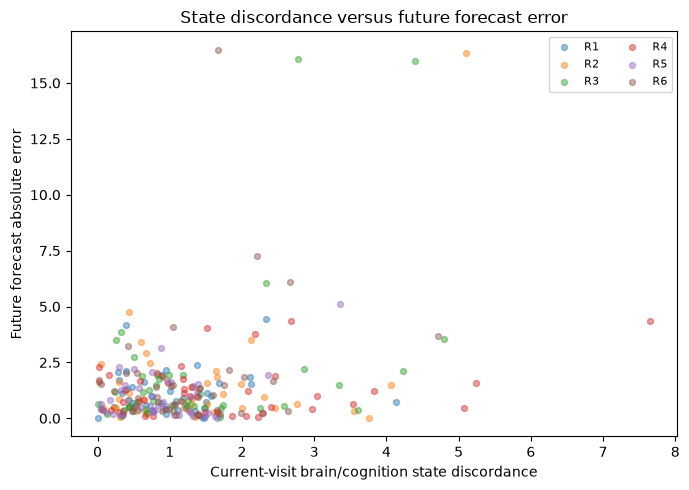

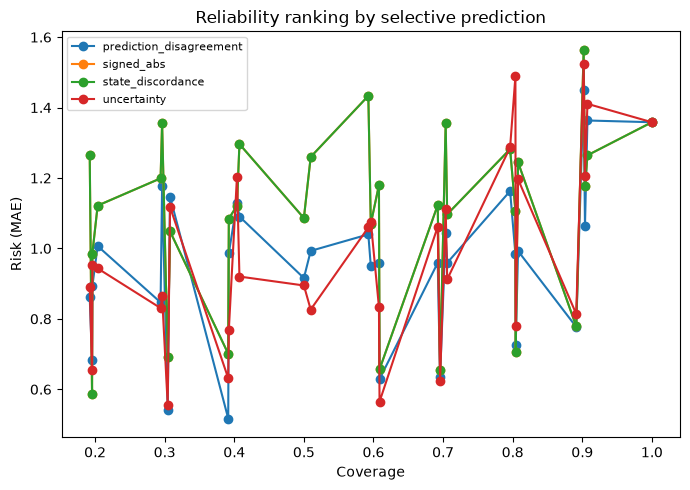

In [26]:
# ============================================================
# 14. PAPER FIGURES
# ============================================================
fig_dir=OUT_ROOT/"figures"
fig_dir.mkdir(exist_ok=True)

# Figure A: subject-level state discordance vs future error, all held-out repeats.
p=test_state.copy()
p=p.groupby(["repeat","subject_id"],as_index=False).agg(
    state_discordance=("state_discordance","mean"),
    abs_error=("abs_error","mean")
)
plt.figure(figsize=(7,5))
for rep,g in p.groupby("repeat"):
    plt.scatter(g["state_discordance"],g["abs_error"],s=18,alpha=.45,label=f"R{rep}")
plt.xlabel("Current-visit brain/cognition state discordance")
plt.ylabel("Future forecast absolute error")
plt.title("State discordance versus future forecast error")
plt.legend(ncol=2,fontsize=8)
plt.tight_layout()
plt.savefig(fig_dir/"state_discordance_vs_error.png",dpi=220)
plt.show()

# Figure B: risk-coverage comparison.
if not selective.empty:
    plt.figure(figsize=(7,5))
    for score,g in selective.groupby("score"):
        g2=g.groupby("coverage",as_index=False)["MAE"].mean()
        plt.plot(g2["coverage"],g2["MAE"],marker="o",label=score)
    plt.xlabel("Coverage")
    plt.ylabel("Risk (MAE)")
    plt.title("Reliability ranking by selective prediction")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(fig_dir/"risk_coverage_comparison.png",dpi=220)
    plt.show()